# 线性回归教程：用 BMI 预测糖尿病疾病进展

本教程使用 scikit-learn 内置的
[`load_diabetes`](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_diabetes.html)
数据集，训练一个只使用 **BMI** 特征的线性回归模型。单特征设计便于把观测值和回归线画在同一张二维图中。

> 说明：这个示例用于学习回归建模流程，不应被用于医学诊断。

## Goal

完成本教程后，你将能够：

- 从 scikit-learn 加载内置示例数据集；
- 选择单个 BMI 特征并划分训练集、测试集；
- 使用 `LinearRegression` 拟合模型；
- 计算 MSE、RMSE 和 R²；
- 在 Jupyter 中用散点图和回归线检查模型结果。

## Setup

运行下面的单元格导入依赖并固定参数。`%matplotlib inline` 是 Jupyter 魔法命令，
用于让 Matplotlib 图表直接显示在 Notebook 中。

In [1]:
%matplotlib inline

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

TEST_SIZE = 0.20

print(f"scikit-learn: {sklearn.__version__}")
print(f"matplotlib: {matplotlib.__version__}")

scikit-learn: 1.9.0
matplotlib: 3.11.1


## Steps

### 1. 加载内置 Diabetes 数据集

`as_frame=True` 让特征和目标以 pandas 对象返回，便于按列名选择特征。
数据直接来自 scikit-learn，不需要下载外部文件。

In [2]:
diabetes = load_diabetes(as_frame=True)
features = diabetes.data.copy()
target = diabetes.target.rename("disease_progression")

print(f"Samples: {features.shape[0]}")
print(f"Features: {features.shape[1]}")
print(f"Feature names: {features.columns.tolist()}")
features.head()

Samples: 442
Features: 10
Feature names: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


### 2. 选择 BMI 单特征

Diabetes 数据集中的特征已经过标准化。这里保留二维表结构 `[['bmi']]`，
以符合 scikit-learn 对输入特征矩阵的要求。

In [3]:
X = features.loc[:, ["bmi"]].copy()
y = target.copy()

selected_data = pd.concat([X, y], axis=1)
selected_data.describe().round(3)

,bmi,disease_progression
count,442.000,442.000
mean,-0.000,152.133
std,0.048,77.093
min,-0.090,25.000
25%,-0.034,87.000
50%,-0.007,140.500
75%,0.031,211.500
max,0.171,346.000


### 3. 划分训练集和测试集

使用 80% 数据训练、20% 数据测试，并设置 `random_state=42`。
固定随机种子可以让每次运行得到完全相同的数据划分。

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=42,
    shuffle=True,
)

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")

Training samples: 353
Test samples: 89


### 4. 训练线性回归模型

模型学习一条直线：

\[
\hat{y} = \beta_0 + \beta_1 \times \mathrm{BMI}
\]

其中，`intercept_` 是截距 \(\beta_0\)，`coef_[0]` 是 BMI 的系数 \(\beta_1\)。

In [5]:
model = LinearRegression()
model.fit(X_train, y_train)

print(f"Intercept: {model.intercept_:.3f}")
print(f"BMI coefficient: {model.coef_[0]:.3f}")

Intercept: 152.003
BMI coefficient: 998.578


### 5. 预测并评估模型

- **MSE（均方误差）**：预测误差平方的平均值，越小越好；
- **RMSE（均方根误差）**：与目标变量单位一致，越小越好；
- **R²（决定系数）**：衡量模型解释测试集变异的程度，最高为 1，也可能为负数。

In [6]:
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

metrics = pd.DataFrame(
    {
        "Metric": ["MSE", "RMSE", "R²"],
        "Value": [mse, rmse, r2],
    }
)
metrics.round(3)

,Metric,Value
0,MSE,4061.826
1,RMSE,63.732
2,R²,0.233


### 6. 绘制测试集散点图和回归线

为了让回归线连续显示，先按 BMI 对测试样本排序。图表标题和坐标轴使用英文，
避免本地环境缺少中文字体时出现乱码。

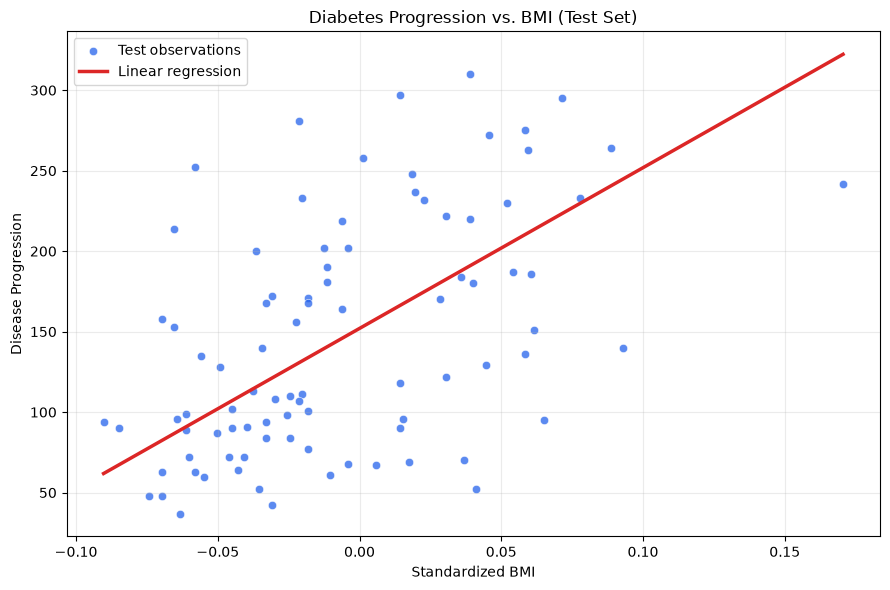

In [7]:
bmi_test = X_test["bmi"].to_numpy()
sort_order = np.argsort(bmi_test)

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(
    bmi_test,
    y_test.to_numpy(),
    color="#2563EB",
    alpha=0.75,
    edgecolors="white",
    linewidth=0.5,
    label="Test observations",
)
ax.plot(
    bmi_test[sort_order],
    y_pred[sort_order],
    color="#DC2626",
    linewidth=2.5,
    label="Linear regression",
)
ax.set_title("Diabetes Progression vs. BMI (Test Set)")
ax.set_xlabel("Standardized BMI")
ax.set_ylabel("Disease Progression")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## Checks

下面的断言检查输入、输出和指标是否符合预期。如果任一条件不满足，
Notebook 会立即报错，帮助定位问题。

In [8]:
assert X.columns.tolist() == ["bmi"], "Model input must contain only BMI."
assert X.shape[1] == 1, "Expected exactly one input feature."
assert not X.isna().any().any(), "BMI contains missing values."
assert not y.isna().any(), "Target contains missing values."
assert len(y_pred) == len(y_test), "Prediction count does not match test data."
assert mse >= 0 and rmse >= 0, "Error metrics must be non-negative."
assert np.isfinite([mse, rmse, r2]).all(), "Metrics must be finite."
assert np.isclose(rmse**2, mse), "RMSE squared should equal MSE."

print("All checks passed.")

All checks passed.


### 查看部分预测结果

残差定义为“实际值减去预测值”。这里仅显示前 10 条记录，避免产生过大的输出。

In [9]:
prediction_comparison = pd.DataFrame(
    {
        "BMI": X_test["bmi"].to_numpy(),
        "Actual": y_test.to_numpy(),
        "Predicted": y_pred,
        "Residual": y_test.to_numpy() - y_pred,
    }
)
prediction_comparison.head(10).round(3)

,BMI,Actual,Predicted,Residual
0,-0.006,219.0,145.806,73.194
1,0.037,70.0,188.857,-118.857
2,-0.004,202.0,147.959,54.041
3,0.052,230.0,203.925,26.075
4,-0.020,111.0,131.815,-20.815
5,-0.025,84.0,127.509,-43.509
6,0.171,242.0,322.316,-80.316
7,0.046,272.0,197.468,74.532
8,-0.090,94.0,61.856,32.144
9,0.015,96.0,167.332,-71.332


## Next Steps

可以在这个基础上继续尝试：

1. 同时使用全部 10 个特征，比较多元线性回归与 BMI 单特征模型的 R²；
2. 绘制残差图，检查误差是否存在明显模式；
3. 使用交叉验证代替单次训练/测试划分；
4. 比较 Ridge、Lasso 等带正则化的线性模型；
5. 改变 `TEST_SIZE`，观察评估指标的稳定性。